# Multi-Perspective Segmentation Project

## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook combines **Demographic** and **Behavioral** perspectives to create a unified customer segmentation.
- Demographic clusters describe *who* the customers are.
- Behavioral clusters describe *how* they behave.

## Imports

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import umap
import warnings

from sklearn.preprocessing import  MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load Data

In [15]:
demographic = pd.read_csv('demographic_clusters.csv')
behavioral = pd.read_csv('behavioral_clusters_year.csv')
behavioral_m = pd.read_csv('behavioral_clusters_month.csv')
value_based = pd.read_csv('value_based_clusters.csv')

df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

In [42]:
print(demographic['Demographic_Cluster_Name'].nunique())
print(behavioral['Behavioral_Year_Cluster_Name'].nunique())
print(behavioral_m['Behavioral_Month_Cluster_Name'].nunique())
print(value_based['Value_Based_Cluster_Name'].nunique())

4
9
15
9


##  Merge Perspectives
We join both perspectives using a common identifier (Loyalty#).

In [16]:
df_multi_perspective = (df_AIAI_Master_Complete
             .merge(demographic, on='Loyalty#', how='inner')
             .merge(behavioral, on='Loyalty#', how='inner')
             .merge(behavioral_m, on='Loyalty#', how='inner')
             .merge(value_based, on='Loyalty#', how='inner')).copy()
df_multi_perspective.head()

,Loyalty#,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,...,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
0,480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,...,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics
1,549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,...,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\r\n(2020),Avr|Point Acumulator\n(No companions),Fly fanatics
2,429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,...,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556,Low-Income West,Lost custumers\r\n(Traveled more before),Avr|Dec Companion\n(Less travel on dec),Lost Occasional Travelers
3,608370,Queen,Hagee,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,...,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270,Low-Income East,Formers Points accumulator\r\n(2020),Avr|Jan Companion\n(Less travel on jan),Long-tenure
4,530508,Claire,Latting,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,...,55.3928,73.4215,68.3248,0.0000,40.8525,2.1200,High-Income East,Points accumulator currently\r\n(2021),Avr|Mar Companion\n(Less travel on mar),Fly fanatics


In [17]:
df_multi_perspective.set_index('Loyalty#', inplace=True)

In [18]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 90 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   First Name                             16572 non-null  object        
 1   Last Name                              16572 non-null  object        
 2   Customer Name                          16572 non-null  object        
 3   Province or State                      16572 non-null  object        
 4   City                                   16572 non-null  object        
 5   Latitude                               16572 non-null  float64       
 6   Longitude                              16572 non-null  float64       
 7   Postal code                            16572 non-null  object        
 8   Gender                                 16572 non-null  object        
 9   Education                              16572 non-null  objec

In [19]:
# list of columns to remove
cols_to_remove = ['First Name', 'Last Name', 'Customer Name', 'Postal code',  
                  'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType','Re_engaged_people']

# Drop them 
df_multi_perspective.drop(inplace=True,columns=cols_to_remove)

In [20]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 82 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Province or State                      16572 non-null  object 
 1   City                                   16572 non-null  object 
 2   Latitude                               16572 non-null  float64
 3   Longitude                              16572 non-null  float64
 4   Gender                                 16572 non-null  object 
 5   Education                              16572 non-null  object 
 6   Location Code                          16572 non-null  object 
 7   Income                                 16572 non-null  float64
 8   Marital Status                         16572 non-null  object 
 9   LoyaltyStatus                          16572 non-null  object 
 10  Customer Lifetime Value                16572 non-null  float64
 11  D

## Outliers

In [21]:
columns_to_remove = ['Customer Lifetime Value',
                     'Dollar_Cost_Points_Remaining_month_1','Dollar_Cost_Points_Remaining_month_2',
                     'Dollar_Cost_Points_Remaining_month_3','Dollar_Cost_Points_Remaining_month_4',
                     'Dollar_Cost_Points_Remaining_month_5','Dollar_Cost_Points_Remaining_month_6',
                     'Dollar_Cost_Points_Remaining_month_7','Dollar_Cost_Points_Remaining_month_8',
                     'Dollar_Cost_Points_Remaining_month_9', 'Dollar_Cost_Points_Remaining_month_10', 
                     'Dollar_Cost_Points_Remaining_month_11', 'Dollar_Cost_Points_Remaining_month_12']

for col in columns_to_remove:
   q1 = df_multi_perspective[col].quantile(0.25)
   q3 = df_multi_perspective[col].quantile(0.75)
   iqr = q3 - q1
   lower_extreme = q1 - 3 * iqr
   upper_extreme = q3 + 3 * iqr

   df_multi_perspective[col] = df_multi_perspective[col].clip(lower=lower_extreme, upper=upper_extreme)

In [22]:
df_multi_perspective['Recency_Days'] = df_multi_perspective['Recency_Days'].clip(upper=365)

In [23]:
df_multi_perspective['Dollar_Cost_Points_Remaining'] = df_multi_perspective['Dollar_Cost_Points_Remaining'].clip(lower=0)

In [46]:
df_multi_perspective.head()

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,3839.14,1049,0.0,191.0,497375.0,29.319372,362.1394,29.0,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,3839.61,1027,0.0,279.0,389939.0,11.469534,165.2639,29.0,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-142.9017,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\r\n(2020),Avr|Point Acumulator\n(No companions),Fly fanatics
429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,3839.75,1274,0.0,120.0,229821.0,33.333333,174.9763,363.0,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764

## Missing Values

In [24]:
df_multi_perspective.isna().sum()

Province or State                           0
City                                        0
Latitude                                    0
Longitude                                   0
Gender                                      0
                                         ... 
Dollar_Cost_Points_Remaining_month_12    1471
Demographic_Cluster_Name                    0
Behavioral_Year_Cluster_Name                0
Behavioral_Month_Cluster_Name               0
Value_Based_Cluster_Name                    0
Length: 82, dtype: int64

In [25]:
df_multi_perspective.fillna(0, inplace=True)

## Scaling

In [26]:
columns_to_drop=['Province or State','City','Gender','Education','Location Code','Marital Status','LoyaltyStatus',
                 'Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name','Value_Based_Cluster_Name', 'Behavioral_Month_Cluster_Name']
df_for_modeling = df_multi_perspective.drop(columns_to_drop, axis=1)

In [27]:
df_for_modeling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 71 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Latitude                               16572 non-null  float64
 1   Longitude                              16572 non-null  float64
 2   Income                                 16572 non-null  float64
 3   Customer Lifetime Value                16572 non-null  float64
 4   Days_with_us                           16572 non-null  int64  
 5   Days_until_reengagement                16572 non-null  float64
 6   Total_NumFlights                       16572 non-null  float64
 7   Total_DistanceKM                       16572 non-null  float64
 8   Perc_Flights_With_Companions           16572 non-null  float64
 9   Dollar_Cost_Points_Remaining           16572 non-null  float64
 10  Recency_Days                           16572 non-null  float64
 11  T

In [32]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_for_modeling),
    index=df_for_modeling.index,
    columns=df_for_modeling.columns
)

In [33]:
df_for_modeling.head()

,Latitude,Longitude,Income,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,...,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,-0.924640,0.352217,0.403187,-0.823392,-0.148884,-1.0,0.094556,0.395690,-0.413613,0.110600,...,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.190720,-0.476201,-1.000000,-0.823349,-0.166734,-1.0,0.598854,0.094212,-0.770609,-0.493173,...,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,-0.289838,-0.710093,-1.000000,-0.823336,0.033671,-1.0,-0.312321,-0.355097,-0.333333,-0.463387,...,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.924640,0.352217,-1.000000,-0.823336,0.738742,-1.0,0.123209,0.083243,-0.408163,-0.317210,...,0.717038,0.493880,0.440563,0.429871,0.086147,0.086398,0.178134,0.675157,0.438929,0.022709
530508,-0.724428,0.441351,0.957012,-0.823060,0.238945,-1.0,-0.020057,0.028757,-0.263158,0.124095,...,0.119040,0.059578,0.527517,0.501992,0.507169,0.707008,0.788100,0.094675,0.574629,0.130157


In [34]:
umap_for_modeling= df_for_modeling.copy()

In [35]:
df_size = df_multi_perspective.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name', 
                                        'Behavioral_Month_Cluster_Name', 'Value_Based_Cluster_Name']).size()
df_size

Demographic_Cluster_Name  Behavioral_Year_Cluster_Name              Behavioral_Month_Cluster_Name            Value_Based_Cluster_Name   
High-Income East          Consistent low travelers\r\n(Use points)  Avr|Dec Companion\n(Less travel on dec)  Fly fanatics                    3
                                                                                                             High-Value Frequent Flyers      3
                                                                                                             High-Value Low transactions     1
                                                                                                             Long-tenure                    21
                                                                                                             New engaged                    15
                                                                                                                                            ..
Low-I

In [36]:
df_for_modeling['Demographic_Cluster_Name']= df_multi_perspective['Demographic_Cluster_Name']
df_for_modeling['Behavioral_Year_Cluster_Name']= df_multi_perspective['Behavioral_Year_Cluster_Name']
df_for_modeling['Behavioral_Month_Cluster_Name']= df_multi_perspective['Behavioral_Month_Cluster_Name']
df_for_modeling['Value_Based_Cluster_Name']= df_multi_perspective['Value_Based_Cluster_Name']

In [37]:
df_centroids = df_for_modeling.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name',
                                         'Behavioral_Month_Cluster_Name','Value_Based_Cluster_Name']).mean()
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                 -0.186616   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                  -0.609297   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High

## Hierarchical

In [21]:
linkage_matrix= linkage(df_centroids, method="ward")

In [22]:
linkage_matrix.shape

(1273, 4)

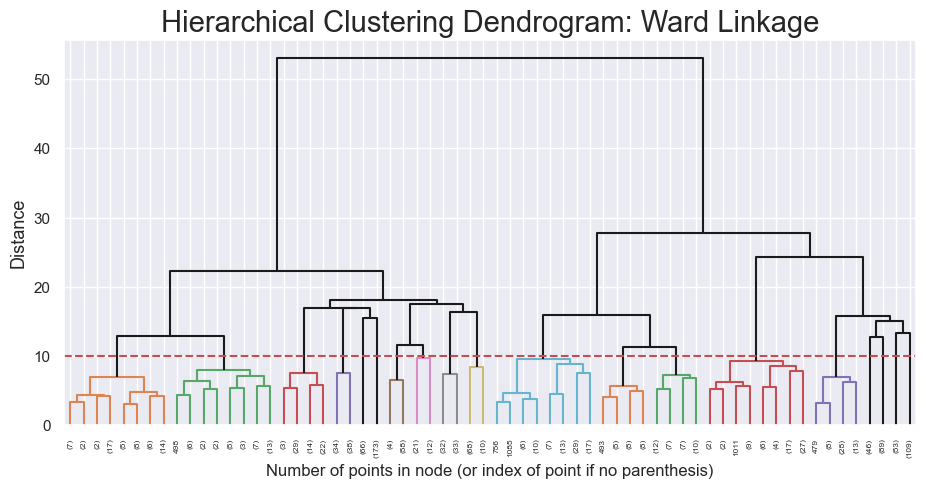

In [23]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 10
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [24]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=5)
hc_labels = hclust.fit_predict(df_centroids)
hc_labels

array([0, 0, 3, ..., 0, 0, 0])

In [25]:
df_centroids['merged_labels'] = hc_labels
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                 -0.186616   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                  -0.609297   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High

In [26]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  


{('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Dec Companion\n(Less travel on dec)',
  'Fly fanatics'): 0,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Dec Companion\n(Less travel on dec)',
  'High-Value Frequent Flyers'): 0,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Dec Companion\n(Less travel on dec)',
  'High-Value Low transactions'): 3,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Dec Companion\n(Less travel on dec)',
  'Long-tenure'): 0,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Dec Companion\n(Less travel on dec)',
  'New engaged'): 0,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Feb Companion\n(Less travel on feb)',
  'Fly fanatics'): 0,
 ('High-Income East',
  'Consistent low travelers\r\n(Use points)',
  'Avr|Feb Companion\n(Less travel on feb)',
  'High-Value Frequent Flyers'): 0,
 ('High-Income

In [27]:
inverse_cluster_mapper = {}

for key, value in cluster_mapper.items():
    # If the value isn't in the new dict yet, create a list
    if value not in inverse_cluster_mapper:
        inverse_cluster_mapper[value] = []
    
    # Append the original key to that list
    inverse_cluster_mapper[value].append(key)
inverse_cluster_mapper

{0: [('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'Fly fanatics'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'Long-tenure'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'New engaged'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Feb Companion\n(Less travel on feb)',
   'Fly fanatics'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Feb Companion\n(Less travel on feb)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Feb Companion\n(Less travel on feb)',
   'Long-tenure'),
  ('High-Income East

In [29]:
df_multi_perspective['merged_labels'] = df_multi_perspective.apply(
    lambda row: cluster_mapper[(row['Demographic_Cluster_Name'], row['Behavioral_Year_Cluster_Name'], row['Behavioral_Month_Cluster_Name'], row['Value_Based_Cluster_Name'])],
    axis=1
)
df_multi_perspective

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,...,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,...,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics,0
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,...,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\r\n(2020),Avr|Point Acumulator\n(No companions),Fly fanatics,0
429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,...,16.8765,56.8163,0.0000,1.0278,45.7556,Low-Income West,Lost custumers\r\n(Traveled more before),Avr|Dec Companion\n(Less travel on dec),Lost Occasional Travelers,3
608370,Ontario,Toronto,43.653225,-79.383186,male,College,Suburban,0.0,Single,Star,...,0.0000,9.2783,53.1249,29.2410,-10.2270,Low-Income East,Formers Points accumulator\r\n(2020),Avr|Jan Companion\n(Less travel on jan),Long-tenure,0
530508,Quebec,Hull,45.428730,-75.713364,male,Bachelor,Suburban,97832.0,Married,Star,...,73.4215,68.3248,0.0000,40.8525,2.1200,High-Income East,Points accumulator currently\r\n(2021),Avr|Mar Companion\n(Less travel on mar),Fly fanatics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823768,British Columbia,Vancouver,49.282730,-123.120740,female,College,Rural,0.0,Married,Star,...,62.3969,73.6945,10.2700,0.0000,92.2102,Low-Income West,Stable average travelers\r\n(Loyal),Avr|Point Acumulator\n(No companions),High-Value Frequent Flyers,0
680886,Saskatchewan,Regina,50.445210,-104.618900,female,Bachelor,Rural,78310.0,Married,Star,...,-47.4300,-26.0539,0.4300,3.0301,20.2400,High-Income West,Stable average travelers\r\n(Loyal),Avr|Point Acumulator\n(No companions),High-Value Frequent Flyers,0
776187,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,...,76.9234,11.6135,-65.5510,29.2889,23.5600,Low-Income West,Stable average travelers\r\n(Loyal),Avr|Oct Companion\n(Less travel on oct),High-Value Frequent Flyers,0


In [30]:
print(df_multi_perspective['merged_labels'].value_counts().sort_index())

merged_labels
0    9237
1    1315
2    4762
3     190
4    1068
Name: count, dtype: int64


c:\Users\luisb\anaconda3\envs\DM2526\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


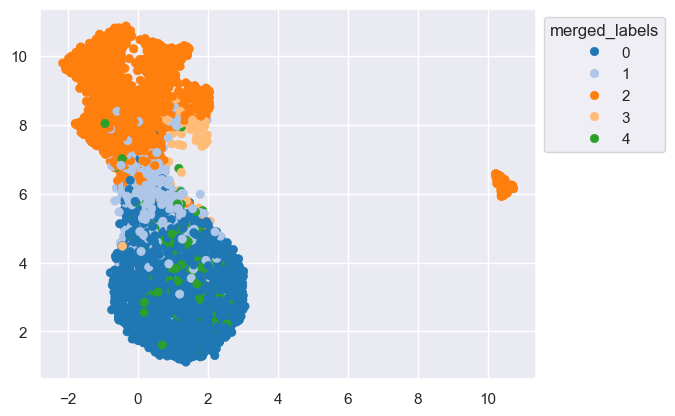

In [31]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(umap_for_modeling)
targets = df_multi_perspective['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
# full profiling (numerical and categorical)
# c-means
# autoencoder